In [6]:
# Cell 1 — Setup + hourly Binance + PIT universe + entry signals (Stage 1)
# PIT: each month, top-N liquid chosen using ONLY data through last bar of prior month.
# Signals (trend/pullback/down) are causal rolls; entry only where monthly pit_universe is True.
# FAST_MODE: TOP_N=20 for smoke; full run sets FAST_MODE=False.
# Data: loads data/binance_hourly_top50_pool.parquet (REFRESH_BINANCE_CACHE=False = no API download).
# Colab: mount Drive — data at MyDrive/backtest_engine2/data/*.parquet; library at MyDrive/backtest_engine.

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests

for _eng in [
    Path("/content/drive/MyDrive/backtest_engine"),
    Path("/content/backtest_engine"),
    Path(r"C:\Users\User\backtest_engine"),
    Path("..").resolve() / "backtest_engine",
]:
    if (_eng / "backtest").is_dir():
        sys.path.insert(0, str(_eng))
        break
else:
    raise FileNotFoundError("backtest_engine not found — mount Drive or set path in Cell 1")
from backtest.data import DataPanel, FieldSpec

# ── FAST_MODE / crypto params (Cell 2 will mirror these) ─────────────────────
FAST_MODE = True

CRYPTO_TOP_N = 20 if FAST_MODE else 50
W_LIQ = 168          # median quote-volume lookback (hours)
T_TREND = 168        # uptrend window (hours)
R_MIN = 0.06         # min cumulative log return for uptrend (2a)
L_MA = 24            # pullback SMA (hours)
RECENT_DOWN_BARS = 1 # 3B: require negative log return on last N bar(s)
MIN_HISTORY_FRAC = 0.9

STABLE_EXCLUDE = frozenset({
    "USDTUSDT", "USDCUSDT", "USDSUSDT", "USDEUSDT", "USD1USDT", "BFUSDUSDT",
    "UUSDT", "RLUSDUSDT", "PAXGUSDT", "XAUTUSDT", "EURUSDT", "FDUSDUSDT",
    "TUSDUSDT", "USDPUSDT",
})

START_UTC = pd.Timestamp("2019-01-01", tz="UTC")
END_UTC = pd.Timestamp.now(tz="UTC").floor("h")
MATIC_TO_POL_DATE = pd.Timestamp("2024-09-04", tz="UTC")

CACHE_DIR = Path("data")
CACHE_DIR.mkdir(exist_ok=True)
BINANCE_CACHE = CACHE_DIR / "binance_hourly_top50_pool.parquet"
# False = use existing parquet only (Colab/local). True = incremental API fetch for missing symbols.
REFRESH_BINANCE_CACHE = False

BINANCE_KLINES = "https://api.binance.com/api/v3/klines"
BINANCE_INFO = "https://api.binance.com/api/v3/exchangeInfo"

KLINES_COLS = [
    "open_time", "open", "high", "low", "close", "base_volume", "close_time",
    "quote_volume", "n_trades", "taker_buy_base", "taker_buy_quote", "ignored",
]

ANCHOR_BINANCE = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT",
    "DOGEUSDT", "ADAUSDT", "SHIBUSDT", "AVAXUSDT", "DOTUSDT",
    "LINKUSDT", "TRXUSDT", "BCHUSDT", "NEARUSDT", "MATICUSDT",
    "UNIUSDT", "LTCUSDT", "ICPUSDT", "ETCUSDT", "HBARUSDT",
    "ATOMUSDT", "FILUSDT", "APTUSDT", "ARBUSDT", "OPUSDT",
    "INJUSDT", "SUIUSDT", "SEIUSDT", "TIAUSDT", "LDOUSDT",
]


def fetch_binance_usdt_set(session=None):
    sess = session or requests.Session()
    r = sess.get(BINANCE_INFO, timeout=30)
    r.raise_for_status()
    return {
        s["symbol"]
        for s in r.json()["symbols"]
        if s.get("quoteAsset") == "USDT"
        and s.get("status") == "TRADING"
        and s.get("isSpotTradingAllowed") is not False
    }


def fetch_klines(symbol, start_ms, end_ms, session=None):
    sess = session or requests.Session()
    out, cur = [], start_ms
    while cur <= end_ms:
        params = dict(symbol=symbol, interval="1h", startTime=cur, endTime=end_ms, limit=1000)
        for attempt in range(5):
            r = sess.get(BINANCE_KLINES, params=params, timeout=30)
            if r.status_code == 200:
                break
            if r.status_code in (429, 418):
                time.sleep(2 ** attempt)
                continue
            if r.status_code == 400:
                return pd.DataFrame(columns=KLINES_COLS).set_index("open_time")
            r.raise_for_status()
        else:
            raise RuntimeError(f"{symbol}: too many retries at {cur}")
        rows = r.json()
        if not rows:
            break
        out.extend(rows)
        last_open = rows[-1][0]
        if len(rows) < 1000:
            break
        cur = last_open + 3_600_000
        time.sleep(0.12)
    if not out:
        return pd.DataFrame(columns=KLINES_COLS).set_index("open_time")
    df = pd.DataFrame(out, columns=KLINES_COLS)
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    for c in ["open", "high", "low", "close", "base_volume", "quote_volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df.set_index("open_time").sort_index()[~df.index.duplicated()]


# ── 1) Load / extend Binance hourly cache ─────────────────────────────────────
if not BINANCE_CACHE.exists():
    raise FileNotFoundError(
        f"Missing {BINANCE_CACHE}. Run hurst_optimal_exit_pairs.ipynb Cell 1 once, "
        "or we can add a full fetch path in a follow-up cell."
    )

raw = pd.read_parquet(BINANCE_CACHE)
raw["open_time"] = pd.to_datetime(raw["open_time"], utc=True)
have = set(raw["symbol"].unique())
target_symbols = sorted(s for s in ANCHOR_BINANCE if s in have)
# Full pool from cache; FAST_MODE only lowers CRYPTO_TOP_N (20 vs 50).
print(f"Loaded {BINANCE_CACHE.name}: {len(have)} symbols, {len(raw):,} rows")
print(f"FAST_MODE={FAST_MODE}  CRYPTO_TOP_N={CRYPTO_TOP_N}  REFRESH_BINANCE_CACHE={REFRESH_BINANCE_CACHE}")

start_ms = int(START_UTC.timestamp() * 1000)
end_ms = int(END_UTC.timestamp() * 1000)
need = [s for s in target_symbols if s not in have and s != "POLUSDT"]
if REFRESH_BINANCE_CACHE and need and not FAST_MODE:
    session = requests.Session()
    binance_usdt = fetch_binance_usdt_set(session)
    need = [s for s in target_symbols if s not in have and s not in binance_usdt and s != "POLUSDT"]
    print(f"Incremental fetch for {len(need)} symbols ...")
    pieces = []
    for i, sym in enumerate(need, 1):
        t0 = time.time()
        df = fetch_klines(sym, start_ms, end_ms, session=session)
        print(f"  [{i:3d}/{len(need)}] {sym:12s} bars={len(df):7,d}  {time.time()-t0:5.1f}s")
        if df.empty:
            continue
        pieces.append(
            df[["close", "quote_volume"]].reset_index().assign(symbol=sym)
        )
    if pieces:
        raw = pd.concat([raw, pd.concat(pieces, ignore_index=True)], ignore_index=True)
        raw.to_parquet(BINANCE_CACHE)
        print(f"Updated cache -> {BINANCE_CACHE}")

matic = raw[raw["symbol"] == "MATICUSDT"]
pol = raw[raw["symbol"] == "POLUSDT"]
if not matic.empty and not pol.empty:
    matic_keep = matic[matic["open_time"] < MATIC_TO_POL_DATE]
    pol_keep = pol[pol["open_time"] >= MATIC_TO_POL_DATE]
    stitched = pd.concat([matic_keep, pol_keep], ignore_index=True).assign(symbol="MATICUSDT")
    raw_x = pd.concat(
        [raw[~raw["symbol"].isin(["MATICUSDT", "POLUSDT"])], stitched],
        ignore_index=True,
    )
else:
    raw_x = raw.copy()

trade_cols = sorted({s for s in raw_x["symbol"].unique() if s != "POLUSDT"})
close = raw_x.pivot(index="open_time", columns="symbol", values="close").reindex(columns=trade_cols)
qvol = raw_x.pivot(index="open_time", columns="symbol", values="quote_volume").reindex(columns=trade_cols)

full_idx = pd.date_range(close.index.min(), close.index.max(), freq="1h", tz="UTC")
close = close.reindex(full_idx)
qvol = qvol.reindex(full_idx)
close.index = close.index.tz_convert("UTC").tz_localize(None)
qvol.index = qvol.index.tz_convert("UTC").tz_localize(None)

# ── 2) Monthly PIT universe (top-N liquid as of prior month-end) ───────────────
MIN_HISTORY_BARS = max(int(W_LIQ * MIN_HISTORY_FRAC), 24)
_rank_cols = [c for c in close.columns if c not in STABLE_EXCLUDE]

pit_universe = pd.DataFrame(False, index=close.index, columns=close.columns)

for per in close.index.to_period("M").unique():
    month_mask = close.index.to_period("M") == per
    idx = np.flatnonzero(month_mask)
    if idx[0] == 0:
        continue
    t_dec = close.index[idx[0] - 1]

    px_lb = close.loc[:t_dec, _rank_cols].iloc[-W_LIQ:]
    vol_lb = qvol.loc[:t_dec, _rank_cols].iloc[-W_LIQ:]

    n_ok = px_lb.notna().sum()
    last_px = px_lb.iloc[-1]
    eligible = (n_ok >= MIN_HISTORY_BARS) & last_px.notna() & vol_lb.notna().any()

    liq = vol_lb.median()
    liq[~eligible] = np.nan
    ranks = liq.rank(ascending=False, method="min")
    picked = ranks.index[ranks <= CRYPTO_TOP_N]

    pit_universe.loc[month_mask, picked] = True

# ── 3) Causal entry features, masked by PIT universe ─────────────────────────
min_trend = max(T_TREND // 2, 24)
min_ma = max(L_MA // 2, 12)

log_ret = np.log(close / close.shift(1))

roll_trend = log_ret.rolling(T_TREND, min_periods=min_trend).sum()
trend_up = roll_trend > R_MIN

sma = close.rolling(L_MA, min_periods=min_ma).mean()
pullback = close < sma

if RECENT_DOWN_BARS == 1:
    recent_down = log_ret < 0
else:
    recent_down = log_ret.rolling(RECENT_DOWN_BARS, min_periods=RECENT_DOWN_BARS).sum() < 0

entry_signal = pit_universe & trend_up & pullback & recent_down

features = {
    "pit_universe": pit_universe.astype(np.float64),
    "trend_up": trend_up.astype(np.float64),
    "pullback": pullback.astype(np.float64),
    "recent_down": recent_down.astype(np.float64),
    "entry_signal": entry_signal.astype(np.float64),
    "roll_trend": roll_trend.astype(np.float64),
    "sma_pullback": sma.astype(np.float64),
    "log_returns": log_ret.astype(np.float64),
}

feat_spec = FieldSpec(lag=0, missing="drop")
specs = {
    "prices": FieldSpec(lag=0),
    "volume": FieldSpec(lag=0),
    "universe": FieldSpec(lag=0),
    **{k: feat_spec for k in features},
}

panel = DataPanel(
    prices=close,
    volume=qvol,
    features=features,
    universe=pit_universe.astype(bool),
    specs=specs,
    check_outliers=True,
)

# ── 4) Validation output ─────────────────────────────────────────────────────
n_entry = int(entry_signal.sum().sum())
n_pit = int(pit_universe.sum().sum())
by_year = entry_signal.sum(axis=1).resample("YE").sum()
_pit_per_m = pit_universe.sum(axis=1).resample("ME").mean()

print(f"\n-- DataPanel (ou-optimal-trend-pullback Cell 1, PIT) --")
print(f"FAST_MODE          : {FAST_MODE}")
print(f"PIT universe       : monthly top-{CRYPTO_TOP_N} by trailing {W_LIQ}h qvol")
print(f"  decision time    : last bar of prior month (no same-month volume peek)")
print(f"  min history      : {MIN_HISTORY_BARS} valid price bars in lookback")
print(f"Bars               : {len(panel.dates):,}")
print(f"Assets in matrix   : {len(panel.assets_all)}  (broad cache; tradable = universe)")
print(f"Range              : {panel.dates[0]} -> {panel.dates[-1]}")
print(f"NaN prices         : {close.isna().mean().mean():.2%}")
print(f"NaN log_returns    : {log_ret.isna().mean().mean():.2%}")
print(f"Fields             : {panel.available_fields()}")
print(f"\nEntry params: TOP_N={CRYPTO_TOP_N} W_LIQ={W_LIQ} T_TREND={T_TREND} "
      f"R_MIN={R_MIN} L_MA={L_MA} recent_down_bars={RECENT_DOWN_BARS}")
print(f"Bar×asset True: pit_universe={n_pit:,}  entry_signal={n_entry:,}")
print(f"Avg names/month in universe (~{CRYPTO_TOP_N} cap): "
      f"{pit_universe.sum(axis=1).resample('ME').mean().mean():.1f}")
print(f"\nEntry signals per calendar year (sum over assets):")
print(by_year.to_string())

print("\nentry_signal.tail(3) [BTC, ETH, SOL if present]:")
_show = [c for c in ["BTCUSDT", "ETHUSDT", "SOLUSDT"] if c in close.columns]
print(entry_signal[_show].tail(3))

print("\nclose.tail(2):")
print(close[_show].tail(2))

Loaded binance_hourly_top50_pool.parquet: 66 symbols, 2,352,473 rows
FAST_MODE=True  CRYPTO_TOP_N=20  REFRESH_BINANCE_CACHE=False


C:\Users\User\backtest_engine\backtest\data\panel.py:172: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rets = self._prices.pct_change()



-- DataPanel (ou-optimal-trend-pullback Cell 1, PIT) --
FAST_MODE          : True
PIT universe       : monthly top-20 by trailing 168h qvol
  decision time    : last bar of prior month (no same-month volume peek)
  min history      : 151 valid price bars in lookback
Bars               : 64,739
Assets in matrix   : 65  (broad cache; tradable = universe)
Range              : 2019-01-01 00:00:00 -> 2026-05-21 10:00:00
NaN prices         : 44.10%
NaN log_returns    : 44.11%
Fields             : ['prices', 'volume', 'entry_signal', 'log_returns', 'pit_universe', 'pullback', 'recent_down', 'roll_trend', 'sma_pullback', 'trend_up']

Entry params: TOP_N=20 W_LIQ=168 T_TREND=168 R_MIN=0.06 L_MA=24 recent_down_bars=1
Bar×asset True: pit_universe=1,234,204  entry_signal=74,611
Avg names/month in universe (~20 cap): 19.1

Entry signals per calendar year (sum over assets):
2019-12-31     6572
2020-12-31    12504
2021-12-31    14341
2022-12-31     8423
2023-12-31     9880
2024-12-31    11660
2025-1

C:\Users\User\AppData\Local\Temp\ipykernel_33004\90555077.py:248: UserWarning: DataPanel: 18342 bar(s) with |return - median| > 10.0*MAD detected.
  Top examples:
    2025-10-10 USDEUSDT: ret=-6.35%, mad_score=635.5
    2025-10-10 USDEUSDT: ret=+6.05%, mad_score=605.9
    2024-04-13 PAXGUSDT: ret=+19.83%, mad_score=200.8
    2021-01-29 DOGEUSDT: ret=+70.02%, mad_score=170.2
    2021-07-24 DEXEUSDT: ret=+69.51%, mad_score=149.2
  Verify these are real moves, not bad ticks. Pass check_outliers=False to silence.
  panel = DataPanel(


In [7]:
# Cell 2 — OuTrendPullbackStrategy + trend MC calibration (GPU CuPy or CPU Numba) + FILTERS
# Entry: entry_signal (Cell 1) AND engine view.assets from monthly PIT universe.
# Exit: spec pi+/pi- + max_holding_period.
# Colab: Runtime -> GPU, pip install cupy-cuda12x if needed. USE_GPU=auto|true|false
# FILTERS: positive drift, SNR, sigma percentile, pi_width, MC Sharpe >= 0

import os
import subprocess
import sys
import time
from pathlib import Path

try:
    from numba import njit, prange
    HAS_NUMBA = True
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "numba"])
    from numba import njit, prange
    HAS_NUMBA = True

N_CORES = os.cpu_count() or 8
os.environ["NUMBA_NUM_THREADS"] = str(N_CORES)
os.environ.setdefault("OMP_NUM_THREADS", str(N_CORES))

import numpy as np
import pandas as pd

_nb_dir = str(Path.cwd())
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

from backtest.strategy import Strategy
from _mood_helpers_ou_optimal_trend_pullback import _mood_d_max_tau, MOOD_THRESHOLD

# ── Params (keep aligned with Cell 1) ─────────────────────────────────────────
_FAST = globals().get("FAST_MODE", True)
_NUM_PATHS = 10_000 if _FAST else 100_000
_MAX_HOLD = 72  # CHANGED: Was 100, now 72 based on Filter 6 analysis
_OLS_WINDOW = 168
_MAX_POSITIONS = 10
_WEIGHT_PER_POSITION = 0.05
_MAX_NEW_ENTRIES_PER_BAR = 3

# NEW: Entry filter thresholds
_MIN_PI_WIDTH = 5.0      # Filter 4: Reject if corridor too tight
_SIGMA_PERCENTILE = 0.75 # Filter 5: Track 75th percentile, reject if above

_PI_PLUS_GRID = np.arange(0.5, 10.0 + 0.5 * 0.5, 0.5, dtype=np.float64)
_PI_MINUS_GRID = np.arange(-10.0, -0.5 + 0.5 * 0.5, 0.5, dtype=np.float64)


@njit(cache=True)
def _fit_ou_numba(s: np.ndarray, m: float):
    n = len(s)
    if n < 10:
        return np.nan, np.nan
    y = np.empty(n - 1)
    x = np.empty(n - 1)
    for i in range(n - 1):
        y[i] = s[i + 1] - s[i]
        x[i] = s[i] - m
    mx = 0.0
    my = 0.0
    for i in range(n - 1):
        mx += x[i]
        my += y[i]
    mx /= n - 1
    my /= n - 1
    var_x = 0.0
    cov_xy = 0.0
    for i in range(n - 1):
        dx = x[i] - mx
        dy = y[i] - my
        var_x += dx * dx
        cov_xy += dx * dy
    if n - 1 > 1:
        var_x /= n - 2
        cov_xy /= n - 2
    if var_x < 1e-14:
        return np.nan, np.nan
    phi = 1.0 + cov_xy / var_x
    ss = 0.0
    for i in range(n - 1):
        resid = y[i] - (phi - 1.0) * x[i]
        ss += resid * resid
    sigma = np.sqrt(ss / (n - 2)) if n > 2 else np.nan
    if not np.isfinite(phi) or not np.isfinite(sigma) or sigma <= 0.0:
        return np.nan, np.nan
    if phi <= -1.0 or phi >= 1.0:
        return np.nan, np.nan
    return phi, sigma

@njit(cache=True)
def _detect_trend_type(s: np.ndarray):
    """
    Detect if trend is better modeled as linear (ABM) or exponential (GBM).
    Returns: 'abm' or 'gbm'
    """
    n = len(s)
    if n < 10:
        return 'abm'
    
    # Fit linear trend to prices
    x = np.arange(n, dtype=np.float64)
    mx = np.mean(x)
    ms = np.mean(s)
    cov = 0.0
    var_x = 0.0
    for i in range(n):
        dx = x[i] - mx
        ds = s[i] - ms
        cov += dx * ds
        var_x += dx * dx
    slope_linear = cov / var_x if var_x > 0 else 0.0
    
    # Calculate R² for linear fit
    ss_res_linear = 0.0
    ss_tot = 0.0
    for i in range(n):
        pred = ms + slope_linear * (x[i] - mx)
        ss_res_linear += (s[i] - pred) ** 2
        ss_tot += (s[i] - ms) ** 2
    r2_linear = 1.0 - (ss_res_linear / ss_tot) if ss_tot > 0 else 0.0
    
    # Fit linear trend to log prices
    log_s = np.log(s)
    m_log_s = np.mean(log_s)
    cov_log = 0.0
    for i in range(n):
        dx = x[i] - mx
        d_log_s = log_s[i] - m_log_s
        cov_log += dx * d_log_s
    slope_log = cov_log / var_x if var_x > 0 else 0.0
    
    # Calculate R² for log-linear fit
    ss_res_log = 0.0
    ss_tot_log = 0.0
    for i in range(n):
        pred_log = m_log_s + slope_log * (x[i] - mx)
        ss_res_log += (log_s[i] - pred_log) ** 2
        ss_tot_log += (log_s[i] - m_log_s) ** 2
    r2_log = 1.0 - (ss_res_log / ss_tot_log) if ss_tot_log > 0 else 0.0
    
    # Choose model with better fit
    return 'gbm' if r2_log > r2_linear else 'abm'

@njit(cache=True)
def _fit_abm_numba(s: np.ndarray):
    """Fit Arithmetic Brownian Motion: drift + volatility."""
    n = len(s)
    if n < 10:
        return np.nan, np.nan
    
    deltas = np.empty(n - 1)
    for i in range(n - 1):
        deltas[i] = s[i + 1] - s[i]
    
    mu = 0.0
    for i in range(n - 1):
        mu += deltas[i]
    mu /= (n - 1)
    
    var = 0.0
    for i in range(n - 1):
        diff = deltas[i] - mu
        var += diff * diff
    sigma = np.sqrt(var / (n - 2)) if n > 2 else np.nan
    
    if not np.isfinite(mu) or not np.isfinite(sigma) or sigma <= 0.0:
        return np.nan, np.nan
    
    return mu, sigma


@njit(cache=True)
def _fit_gbm_numba(s: np.ndarray):
    """Fit Geometric Brownian Motion: drift + volatility on log-returns."""
    n = len(s)
    if n < 10:
        return np.nan, np.nan
    
    log_returns = np.empty(n - 1)
    for i in range(n - 1):
        if s[i] <= 0 or s[i + 1] <= 0:
            return np.nan, np.nan
        log_returns[i] = np.log(s[i + 1] / s[i])
    
    mu = 0.0
    for i in range(n - 1):
        mu += log_returns[i]
    mu /= (n - 1)
    
    var = 0.0
    for i in range(n - 1):
        diff = log_returns[i] - mu
        var += diff * diff
    sigma = np.sqrt(var / (n - 2)) if n > 2 else np.nan
    
    if not np.isfinite(mu) or not np.isfinite(sigma) or sigma <= 0.0:
        return np.nan, np.nan
    
    return mu, sigma        


@njit(parallel=True, cache=True)
def _calibrate_trend_fused(
    mu: float,
    sigma: float,
    s0: float,
    n_paths: int,
    max_h: int,
    seed: int,
    pi_plus_grid: np.ndarray,
    pi_minus_grid: np.ndarray,
    model_type: int,  # 0 = ABM, 1 = GBM
):
    """Simulate trend paths (ABM or GBM) and find optimal thresholds."""
    np.random.seed(seed & 0xFFFFFFFF)
    n_steps = max_h + 1
    pi_paths = np.empty((n_paths, n_steps))
    
    for i in prange(n_paths):
        si = s0
        pi_paths[i, 0] = 0.0
        for step in range(1, n_steps):
            eps = np.random.randn()
            if model_type == 0:  # ABM
                si = si + mu + sigma * eps
            else:  # GBM
                si = si * np.exp((mu - 0.5 * sigma * sigma) + sigma * eps)
            pi_paths[i, step] = si - s0
    
    n_plus = pi_plus_grid.shape[0]
    n_minus = pi_minus_grid.shape[0]
    best_sharpe = -1.0e300
    best_plus = pi_plus_grid[0]
    best_minus = pi_minus_grid[0]
    
    for ip in range(n_plus):
        pi_p = pi_plus_grid[ip]
        for im in range(n_minus):
            pi_m = pi_minus_grid[im]
            sum_p = 0.0
            sum_sq = 0.0
            for i in range(n_paths):
                exit_idx = max_h
                for j in range(1, n_steps):
                    pi = pi_paths[i, j]
                    if pi >= pi_p or pi <= pi_m:
                        exit_idx = j
                        break
                pnl = pi_paths[i, exit_idx]
                sum_p += pnl
                sum_sq += pnl * pnl
            mean = sum_p / n_paths
            var = (sum_sq - n_paths * mean * mean) / (n_paths - 1) if n_paths > 1 else 0.0
            if var < 1e-24:
                continue
            sharpe = mean / np.sqrt(var)
            if sharpe > best_sharpe:
                best_sharpe = sharpe
                best_plus = pi_p
                best_minus = pi_m
    
    if best_sharpe <= -1.0e299:
        return np.nan, np.nan, np.nan
    return best_plus, best_minus, best_sharpe


# ── GPU calibration (CuPy) — falls back to Numba CPU when no GPU ─────────────
_USE_GPU = os.environ.get("USE_GPU", "auto").lower()  # auto | true | false
_cp = None
HAS_GPU = False


def _try_init_gpu():
    global _cp, HAS_GPU
    if _USE_GPU == "false":
        return
    try:
        import cupy as cp
    except ImportError:
        if _USE_GPU == "true":
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "-q", "cupy-cuda12x"]
            )
            import cupy as cp
        else:
            return
    if cp.cuda.is_available():
        _cp = cp
        HAS_GPU = True


_try_init_gpu()


def _calibrate_trend_gpu(
    mu: float,
    sigma: float,
    s0: float,
    n_paths: int,
    max_h: int,
    seed: int,
    pi_plus_grid: np.ndarray,
    pi_minus_grid: np.ndarray,
    model_type: int,
):
    """Vectorized path sim + grid search on GPU (Colab T4+)."""
    cp = _cp
    rng = cp.random.RandomState(seed & 0xFFFFFFFF)
    n_paths = int(n_paths)
    max_h = int(max_h)
    n_steps = max_h + 1
    eps = rng.standard_normal((n_paths, max_h), dtype=cp.float64)

    pi_paths = cp.empty((n_paths, n_steps), dtype=cp.float64)
    pi_paths[:, 0] = 0.0
    if model_type == 0:
        cum_s = s0 + cp.cumsum(mu + sigma * eps, axis=1)
        pi_paths[:, 1:] = cum_s - s0
    else:
        log_inc = (mu - 0.5 * sigma * sigma) + sigma * eps
        cum_s = s0 * cp.exp(cp.cumsum(log_inc, axis=1))
        pi_paths[:, 1:] = cum_s - s0

    pi = pi_paths[:, 1:]
    best_sharpe = -1.0e300
    best_plus = float(pi_plus_grid[0])
    best_minus = float(pi_minus_grid[0])

    for pi_p in pi_plus_grid:
        for pi_m in pi_minus_grid:
            hit = (pi >= pi_p) | (pi <= pi_m)
            has_hit = hit.any(axis=1)
            first_col = hit.argmax(axis=1)
            exit_col = cp.where(has_hit, first_col + 1, max_h)
            pnl = pi_paths[cp.arange(n_paths), exit_col]
            mean = pnl.mean()
            var = pnl.var(ddof=1) if n_paths > 1 else cp.float64(0.0)
            if float(var) < 1e-24:
                continue
            sharpe = float(mean / cp.sqrt(var))
            if sharpe > best_sharpe:
                best_sharpe = sharpe
                best_plus = float(pi_p)
                best_minus = float(pi_m)

    if best_sharpe <= -1.0e299:
        return np.nan, np.nan, np.nan
    return best_plus, best_minus, best_sharpe


class OuTrendPullbackStrategy(Strategy):
    """Trend + pullback entry (Cell 1 features) + O-U optimal exit thresholds (spec) + FILTERS."""

    rebalance_frequency = "D"

    def __init__(
        self,
        fast_mode: bool = _FAST,
        num_simulated_paths: int | None = None,
        max_holding_period: int = _MAX_HOLD,
        ou_ols_window: int = _OLS_WINDOW,
        max_positions: int = _MAX_POSITIONS,
        weight_per_position: float = _WEIGHT_PER_POSITION,
        max_new_entries_per_bar: int = _MAX_NEW_ENTRIES_PER_BAR,
        pi_plus_grid: np.ndarray | None = None,
        pi_minus_grid: np.ndarray | None = None,
        min_pi_width: float = _MIN_PI_WIDTH,
        sigma_percentile: float = _SIGMA_PERCENTILE,
        mood_threshold: float = MOOD_THRESHOLD,
        mood_warmup: int = 21,
        mood_cooldown: int = 48,
    ):
        self.fast_mode = fast_mode
        self.num_simulated_paths = (
            num_simulated_paths if num_simulated_paths is not None
            else (10_000 if fast_mode else 100_000)
        )
        self.max_holding_period = max_holding_period
        self.ou_ols_window = ou_ols_window
        self.max_positions = max_positions
        self.weight_per_position = weight_per_position
        self.max_new_entries_per_bar = max_new_entries_per_bar
        self._pi_plus_grid = (
            pi_plus_grid if pi_plus_grid is not None else _PI_PLUS_GRID.copy()
        )
        self._pi_minus_grid = (
            pi_minus_grid if pi_minus_grid is not None else _PI_MINUS_GRID.copy()
        )
        self.min_pi_width = min_pi_width
        self.sigma_percentile = sigma_percentile
        self.mood_threshold = mood_threshold
        self.mood_warmup = mood_warmup
        self.mood_cooldown = mood_cooldown
        
        
        self.open_trades: dict = {}
        self.trade_log: list = []       # one row per closed trade (round-trip)
        self.decision_log: list = []    # every entry/exit/reject decision
        self._event_this_bar = False
        self._n_entries = 0
        self._n_exits = 0
        self._n_ou_skipped = 0
        self._mood_buffers = {}
        self._last_changepoint = {}

    def _log_decision(self, decision: str, t, asset: str, **fields):
        row = {"decision": decision, "t": t, "asset": asset}
        row.update(fields)
        self.decision_log.append(row)

    def _check_mood_regime(self, asset, log_ret, t):
        if asset not in self._mood_buffers:
            self._mood_buffers[asset] = []

        self._mood_buffers[asset].append(log_ret)
        t = pd.Timestamp(t)

        if (
            asset in self._last_changepoint
            and (t - self._last_changepoint[asset]) < pd.Timedelta(hours=self.mood_cooldown)
        ):
            return False

        if len(self._mood_buffers[asset]) <= self.mood_warmup:
            return True

        if len(self._mood_buffers[asset]) > 500:
            self._mood_buffers[asset] = self._mood_buffers[asset][-500:]

        buf_arr = np.array(self._mood_buffers[asset], dtype=np.float64)
        dmax, tau = _mood_d_max_tau(buf_arr, len(buf_arr))

        if dmax > self.mood_threshold:
            self._last_changepoint[asset] = t
            self._mood_buffers[asset] = self._mood_buffers[asset][int(tau):]
            return False

        return True

    def _entry_context(self, data, asset: str) -> dict:
        ctx = {}
        for name in ("entry_signal", "trend_up", "pullback", "recent_down", "roll_trend", "log_returns"):
            try:
                f = data.feature(name).iloc[-1]
                if asset in f.index:
                    v = f[asset]
                    if np.isfinite(v):
                        ctx[name] = float(v)
            except (KeyError, AttributeError, TypeError):
                pass
        return ctx

    def __repr__(self):
        return (
            f"OuTrendPullbackStrategy(fast={self.fast_mode},paths={self.num_simulated_paths},"
            f"hold={self.max_holding_period},ols={self.ou_ols_window},"
            f"maxpos={self.max_positions},w={self.weight_per_position},"
            f"max_new={self.max_new_entries_per_bar},"
            f"min_width={self.min_pi_width},sigma_pct={self.sigma_percentile})"
        )

    def required_data(self):
        return {"prices": None, "volume": None, "entry_signal": None}

    @staticmethod
    def _fit_trend(prices: np.ndarray):
        """Fit ABM or GBM based on which fits better."""
        if not HAS_NUMBA:
            s = np.asarray(prices, dtype=float)
            if len(s) < 10 or np.isnan(s).any() or np.any(s <= 0):
                return None
            
            model_type = 'abm'  # Simplified for non-numba
            deltas = np.diff(s)
            mu = float(np.mean(deltas))
            sigma = float(np.std(deltas, ddof=1))
            
            if not np.isfinite(mu) or not np.isfinite(sigma) or sigma <= 0:
                return None
            return model_type, mu, sigma
        
        s = prices.astype(np.float64)
        model_type_str = _detect_trend_type(s)
        
        if model_type_str == 'gbm':
            result = _fit_gbm_numba(s)
        else:
            result = _fit_abm_numba(s)
        
        if result is None or np.isnan(result[0]) or np.isnan(result[1]):
            return None
        
        mu, sigma = result
        return model_type_str, float(mu), float(sigma)
    def _calibrate_thresholds(self, model_type_str, mu, sigma, p0, seed: int):
        model_type_int = 1 if model_type_str == "gbm" else 0
        args = (
            float(mu),
            float(sigma),
            float(p0),
            int(self.num_simulated_paths),
            int(self.max_holding_period),
            int(seed),
            self._pi_plus_grid,
            self._pi_minus_grid,
            model_type_int,
        )
        if HAS_GPU:
            return _calibrate_trend_gpu(*args)
        if not HAS_NUMBA:
            raise RuntimeError("Numba or GPU (CuPy) required for trend calibration")
        return _calibrate_trend_fused(*args)
    def _try_enter(self, asset: str, prices: pd.Series, t, ctx: dict | None = None) -> bool:
        ctx = dict(ctx or {})
        log_ret = ctx.get("log_returns", np.nan)
        if np.isfinite(log_ret):
            mood_ok = self._check_mood_regime(asset, log_ret, t)
            if not mood_ok:
                self._n_ou_skipped += 1
                self._log_decision(
                    "entry_reject", t, asset,
                    reason="regime_changepoint",
                    mood_cooldown=self.mood_cooldown,
                    buffer_size=len(self._mood_buffers.get(asset, [])),
                    **ctx,
                )
                return False

        hist = prices[asset].dropna()
        if len(hist) < self.ou_ols_window:
            self._n_ou_skipped += 1
            self._log_decision(
                "entry_reject", t, asset, reason="short_history",
                hist_len=int(len(hist)), need=self.ou_ols_window, **ctx,
            )
            return False
        window = hist.iloc[-self.ou_ols_window :]
        p0 = float(window.iloc[-1])
        
        trend_fit = self._fit_trend(window.values)
        if trend_fit is None:
            self._n_ou_skipped += 1
            self._log_decision(
                "entry_reject", t, asset, reason="trend_fit_fail",
                p0=p0, **ctx,
            )
            return False
        
        model_type, mu, sigma = trend_fit
        
        # Filter: Require positive drift for long-only strategy
        if mu <= 0:
            self._n_ou_skipped += 1
            self._log_decision(
                "entry_reject", t, asset, reason="negative_drift",
                mu=float(mu), model_type=model_type, **ctx,
            )
            return False
        
        # Filter: Drift must be significant vs noise (signal-to-noise ratio)
        snr = mu / sigma if sigma > 0 else 0
        if snr < 0.05:
            self._n_ou_skipped += 1
            self._log_decision(
                "entry_reject", t, asset, reason="low_signal_to_noise",
                snr=float(snr), mu=float(mu), sigma=float(sigma), 
                model_type=model_type, **ctx,
            )
            return False
        
        # Optional: Keep sigma filter as volatility check
        window_sigmas = []
        hist_available = len(hist)
        for i in range(max(self.ou_ols_window, hist_available - 500), hist_available, 20):
            if i < self.ou_ols_window:
                continue
            mini_window = hist.iloc[i - self.ou_ols_window : i]
            if len(mini_window) >= self.ou_ols_window:
                trend_test = self._fit_trend(mini_window.values)
                if trend_test is not None:
                    window_sigmas.append(trend_test[2])
        
        if len(window_sigmas) >= 10:
            sigma_threshold = float(np.percentile(window_sigmas, 75))
            if sigma > sigma_threshold:
                self._n_ou_skipped += 1
                self._log_decision(
                    "entry_reject", t, asset, reason="sigma_too_high",
                    sigma=float(sigma), threshold=sigma_threshold, 
                    n_samples=len(window_sigmas), model_type=model_type, **ctx,
                )
                return False
        
        seed = hash((asset, str(t))) % (2**32)
        cal = self._calibrate_thresholds(model_type, mu, sigma, p0, seed)
        pi_plus, pi_minus, ou_sharpe = cal
        if not (np.isfinite(pi_plus) and np.isfinite(pi_minus) and np.isfinite(ou_sharpe)):
            self._n_ou_skipped += 1
            self._log_decision(
                "entry_reject", t, asset, reason="ou_calibrate_fail",
                p0=p0, model_type=model_type, mu=float(mu), sigma=float(sigma), **ctx,
            )
            return False
        
        # Filter: Reject if MC Sharpe is too low
        if ou_sharpe < 0.0:  # Stricter for trend models
            self._n_ou_skipped += 1
            self._log_decision(
                "entry_reject", t, asset, reason="ou_sharpe_too_low",
                ou_sharpe=float(ou_sharpe), threshold=0.0, **ctx,
            )
            return False
        
        # NEW FILTER 2: Check pi_width (corridor width)
        pi_width = pi_plus - pi_minus
        if pi_width < self.min_pi_width:
            self._n_ou_skipped += 1
            self._log_decision(
                "entry_reject", t, asset, reason="corridor_too_tight",
                pi_width=float(pi_width), min_required=self.min_pi_width,
                pi_plus=float(pi_plus), pi_minus=float(pi_minus), **ctx,
            )
            return False
        
        trade = {
            "entry_t": t,
            "p0": p0,
            "model_type": model_type,
            "mu": float(mu),
            "sigma": float(sigma),
            "pi_plus": float(pi_plus),
            "pi_minus": float(pi_minus),
            "ou_sharpe": float(ou_sharpe),
            "bars_held": 0,
            "entry_ctx": ctx,
        }
        self.open_trades[asset] = trade
        self._n_entries += 1
        self._event_this_bar = True
        self._log_decision(
            "entry_open", t, asset, reason="accepted",
            p0=p0, model_type=model_type,
            mu=float(mu), sigma=float(sigma),
            snr=float(snr),
            pi_plus=float(pi_plus), pi_minus=float(pi_minus),
            pi_width=float(pi_width),
            ou_sharpe=float(ou_sharpe), weight=self.weight_per_position,
            **ctx,
        )
        return True

    def generate_weights(self, data, t):
        self._event_this_bar = False
        prices = data.prices
        entry_row = data.feature("entry_signal").iloc[-1]
        eligible = set(data.assets)
        weights = pd.Series(0.0, index=prices.columns)

        for asset in list(self.open_trades.keys()):
            if asset not in eligible:
                weights[asset] = self.weight_per_position
                continue
            col = prices[asset] if asset in prices.columns else None
            if col is None or col.empty:
                weights[asset] = self.weight_per_position
                continue
            p = float(col.iloc[-1])
            if not np.isfinite(p):
                weights[asset] = self.weight_per_position
                continue

            trade = self.open_trades[asset]
            trade["bars_held"] += 1
            pi_t = float(p) - trade["p0"]
            
            # Dynamic timeout: exit faster if OU Sharpe was poor at entry
            timeout_limit = (
                48 if trade.get("ou_sharpe", 0) < 0.0
                else self.max_holding_period
            )
            
            exit_now = (
                pi_t >= trade["pi_plus"]
                or pi_t <= trade["pi_minus"]
                or trade["bars_held"] >= timeout_limit
            )
            if exit_now:
                reason = (
                    "pi_plus" if pi_t >= trade["pi_plus"]
                    else "pi_minus" if pi_t <= trade["pi_minus"]
                    else "timeout"
                )
                p_exit = float(p)
                ret_pct = pi_t / trade["p0"] if trade["p0"] else np.nan
                closed = {
                    "asset": asset,
                    "entry_t": trade["entry_t"],
                    "exit_t": t,
                    "bars_held": trade["bars_held"],
                    "p0": trade["p0"],
                    "p_exit": p_exit,
                    "model_type": trade["model_type"],
                    "mu": trade["mu"],
                    "pi_exit": pi_t,
                    "ret_pct": float(ret_pct),
                    "win": bool(pi_t > 0),
                    "exit_reason": reason,
                    "sigma": trade["sigma"],
                    "pi_plus": trade["pi_plus"],
                    "pi_minus": trade["pi_minus"],
                    "ou_sharpe": trade["ou_sharpe"],
                    "entry_ctx": trade.get("entry_ctx"),
                }
                self.trade_log.append(closed)
                self._log_decision(
                    "exit", t, asset, reason=reason,
                    p_exit=p_exit, pi_exit=pi_t, ret_pct=float(ret_pct),
                    win=bool(pi_t > 0), bars_held=trade["bars_held"],
                    pi_plus=trade["pi_plus"], pi_minus=trade["pi_minus"],
                    hit_pi_plus=bool(pi_t >= trade["pi_plus"]),
                    hit_pi_minus=bool(pi_t <= trade["pi_minus"]),
                    **(trade.get("entry_ctx") or {}),
                )
                del self.open_trades[asset]
                self._n_exits += 1
                self._event_this_bar = True
            else:
                weights[asset] = self.weight_per_position

        new_entries = 0
        for asset in eligible:
            if asset in self.open_trades:
                continue
            sig_val = float(entry_row.get(asset, 0.0)) if asset in entry_row.index else 0.0
            if not (np.isfinite(sig_val) and sig_val > 0.5):
                continue
            ctx = self._entry_context(data, asset)
            if len(self.open_trades) >= self.max_positions:
                self._log_decision(
                    "entry_reject", t, asset, reason="max_positions",
                    n_open=len(self.open_trades), cap=self.max_positions, **ctx,
                )
                continue
            if new_entries >= self.max_new_entries_per_bar:
                self._log_decision(
                    "entry_reject", t, asset, reason="max_new_per_bar",
                    cap=self.max_new_entries_per_bar, **ctx,
                )
                continue
            if self._try_enter(asset, prices, t, ctx):
                weights[asset] = self.weight_per_position
                new_entries += 1

        return weights

    def apply_risk(self, proposed, state, data):
        equity = state["equity"]
        if not self._event_this_bar and equity > 0:
            proposed = state["positions"] / equity
        return super().apply_risk(proposed, state, data)


strat = OuTrendPullbackStrategy(fast_mode=_FAST)
print(strat)
try:
    from numba import config as _numba_config
    _nth = _numba_config.NUMBA_NUM_THREADS
except Exception:
    _nth = "?"
_gpu_name = "n/a"
if HAS_GPU:
    try:
        _gpu_name = _cp.cuda.runtime.getDeviceProperties(0)["name"].decode()
    except Exception:
        _gpu_name = "cuda"
print(
    f"Accel: cores={N_CORES}, numba={HAS_NUMBA}, numba_threads={_nth}, "
    f"gpu={HAS_GPU} ({_gpu_name}), USE_GPU={_USE_GPU}"
)
print(
    f"O-U grid: {len(strat._pi_plus_grid)} x {len(strat._pi_minus_grid)} = "
    f"{len(strat._pi_plus_grid) * len(strat._pi_minus_grid)} nodes | "
    f"paths={strat.num_simulated_paths:,}"
)
print(f"FILTERS ENABLED:")
print(f"  max_holding_period  : {strat.max_holding_period}h (was 100h)")
print(f"  min_pi_width        : {strat.min_pi_width} (reject tight corridors)")
print(f"  sigma_percentile    : {strat.sigma_percentile} (reject noisy processes)")

rb = strat.rebalance_dates(panel.dates)
print(f"\nRebalance bars: {len(rb):,} (expect {len(panel.dates):,})")
print(f"required_data(): {strat.required_data()}")
print(f"Warmup hint (Cell 4): >= {max(_OLS_WINDOW, _MAX_HOLD, globals().get('T_TREND', 168), globals().get('W_LIQ', 168))} bars")
print(
    "Trade logging: strat.decision_log (every entry_open / entry_reject / exit), "
    "strat.trade_log (closed round-trips). Save parquet after Cell 4."
)

# ── Warmup + calibration timing (GPU if available, else Numba CPU) ─────────────
_warm = (0.5, 0.01, 100.0, strat.num_simulated_paths, _MAX_HOLD, 42, _PI_PLUS_GRID, _PI_MINUS_GRID, 0)
if HAS_GPU:
    _t0 = time.perf_counter()
    _ = _calibrate_trend_gpu(*_warm)
    _cp.cuda.Stream.null.synchronize()
    print(f"\nGPU warmup (full grid, {strat.num_simulated_paths:,} paths): {(time.perf_counter() - _t0) * 1000:.0f} ms")
if HAS_NUMBA:
    _t0 = time.perf_counter()
    _ = _calibrate_trend_fused(0.5, 0.01, 100.0, 100, 10, 42, _PI_PLUS_GRID[:3], _PI_MINUS_GRID[:3], 0)
    print(f"Numba CPU warmup (tiny grid): {(time.perf_counter() - _t0) * 1000:.0f} ms")

_test_asset = next((a for a in ["BTCUSDT", "ETHUSDT", "SOLUSDT"] if a in panel.assets_all), None)
if _test_asset is None:
    _test_asset = panel.assets_all[0]
_hist_full = close[_test_asset].dropna()
_t_probe = _hist_full.index[int(len(_hist_full) * 0.6)]
if len(_hist_full) >= _OLS_WINDOW:
    _w = _hist_full.loc[:_t_probe].iloc[-_OLS_WINDOW:]
    _p0 = float(_w.iloc[-1])
    _trend = strat._fit_trend(_w.values)
    print(f"\nProbe asset {_test_asset} @ {_t_probe}:")
    print(f"  Trend fit: {_trend}")
    if _trend:
        _t1 = time.perf_counter()
        _cal = strat._calibrate_thresholds(_trend[0], _trend[1], _trend[2], _p0, 42)
        _dt = time.perf_counter() - _t1
        print(f"  Calibrate ({strat.num_simulated_paths:,} paths, full grid): {_dt:.2f}s -> {_cal}")
        _n_sig = int(entry_signal.sum().sum())
        if _n_sig > 0:
            print(
                f"  Worst-case if OU on every signal (not actual entries): "
                f"{_dt * _n_sig / 3600:.1f} hours"
            )
else:
    print(f"Probe: insufficient {_test_asset} history in close panel")

OuTrendPullbackStrategy(fast=True,paths=10000,hold=72,ols=168,maxpos=10,w=0.05,max_new=3,min_width=5.0,sigma_pct=0.75)
Accel: cores=16, numba=True, numba_threads=16, gpu=False (n/a), USE_GPU=auto
O-U grid: 20 x 20 = 400 nodes | paths=10,000
FILTERS ENABLED:
  max_holding_period  : 72h (was 100h)
  min_pi_width        : 5.0 (reject tight corridors)
  sigma_percentile    : 0.75 (reject noisy processes)

Rebalance bars: 64,739 (expect 64,739)
required_data(): {'prices': None, 'volume': None, 'entry_signal': None}
Warmup hint (Cell 4): >= 168 bars
Trade logging: strat.decision_log (every entry_open / entry_reject / exit), strat.trade_log (closed round-trips). Save parquet after Cell 4.
Numba CPU warmup (tiny grid): 545 ms

Probe asset BTCUSDT @ 2023-06-07 07:00:00:
  Trend fit: ('gbm', -7.573508787053975e-05, 0.004082157042349916)
  Calibrate (10,000 paths, full grid): 0.02s -> (7.0, -8.0, -0.007446041028205895)
  Worst-case if OU on every signal (not actual entries): 0.4 hours


In [8]:
# Cell 3 — Costs + liquidity (Stage 3, mandatory per PROTOCOL)
# Long-only crypto hourly: Commission + Spread + sqrt impact; ShortBorrow kept for engine parity.

import pandas as pd

from backtest.costs import (
    Commission,
    Spread,
    MarketImpact,
    ShortBorrow,
    CompositeCostModel,
    LiquidityCap,
)

HOURS_PER_YEAR = 365 * 24
TAKER_BPS = 10
HALF_SPREAD_BPS = 5
IMPACT_K = 10
ADV_LOOKBACK = 168
LIQ_CAP_PCT = 0.10
BORROW_ANNUAL_BPS = 1500  # only applies if strategy shorts; long-only -> ~0 holding

costs = CompositeCostModel([
    Commission(bps=TAKER_BPS),
    Spread(half_bps=HALF_SPREAD_BPS),
    MarketImpact(k=IMPACT_K, kind="sqrt", adv_lookback=ADV_LOOKBACK),
    ShortBorrow(annual_bps=BORROW_ANNUAL_BPS, trading_days=HOURS_PER_YEAR),
])

liq = LiquidityCap(cap_pct=LIQ_CAP_PCT, adv_lookback=ADV_LOOKBACK)

print("Cost components:", [type(m).__name__ for m in costs.models])
for m in costs.models:
    if isinstance(m, Commission):
        print(f"  Commission        bps         = {m.bps}")
    elif isinstance(m, Spread):
        print(f"  Spread            half_bps    = {m.half_bps}")
    elif isinstance(m, MarketImpact):
        print(f"  MarketImpact      k={m.k}, kind={m.kind!r}, adv_lookback={m.adv_lookback}")
    elif isinstance(m, ShortBorrow):
        implied_annual_pct = m.daily_rate * HOURS_PER_YEAR * 100
        print(
            f"  ShortBorrow       per-bar rate={m.daily_rate:.3e}  "
            f"(annualized = {implied_annual_pct:.2f}%)"
        )

print(f"\nLiquidityCap      cap_pct={liq.cap_pct}, adv_lookback={liq.adv_lookback}")
print(f"Panel has volume  : {panel.has_field('volume')}  (required True)")

# Long-only smoke: $10k BTC buy on last bar with valid BTC price
_btc_idx = close["BTCUSDT"].dropna().index
if len(_btc_idx) == 0:
    _probe_t = panel.dates[-1]
    _probe_sym = panel.assets_all[0]
else:
    _probe_t = _btc_idx[-1]
    _probe_sym = "BTCUSDT"

sample_view = panel.as_of(_probe_t)
sample_trades = pd.Series({_probe_sym: 10_000.0}).reindex(panel.assets_all).fillna(0.0)
tc = costs.trade_cost(sample_trades, sample_view)
hc = costs.holding_cost(sample_trades, sample_view)
print(f"\nSmoke test ({_probe_t}, +$10k {_probe_sym} long):")
print(f"  trade_cost   = ${tc:,.2f}   ({tc / 10_000 * 1e4:.1f} bps of $10k notional)")
print(f"  holding_cost = ${hc:,.4f}   (long-only -> expect ~0)")

Cost components: ['Commission', 'Spread', 'MarketImpact', 'ShortBorrow']
  Commission        bps         = 10
  Spread            half_bps    = 5
  MarketImpact      k=10, kind='sqrt', adv_lookback=168
  ShortBorrow       per-bar rate=1.712e-05  (annualized = 15.00%)

LiquidityCap      cap_pct=0.1, adv_lookback=168
Panel has volume  : True  (required True)

Smoke test (2026-05-19 12:00:00, +$10k BTCUSDT long):
  trade_cost   = $15.00   (15.0 bps of $10k notional)
  holding_cost = $0.0000   (long-only -> expect ~0)


In [9]:
# Cell 4 — Rolling walk-forward (1yr OOS steps) — NOT single in-sample
# Each calendar year: fresh strategy, $1M capital, test window only.
# Indicators at t still use history <= t (no future prices). Stitched OOS metrics.
# Set RUN_SINGLE_IN_SAMPLE=True for one full-history smoke run only.

import time
from pathlib import Path

import numpy as np
import pandas as pd

from backtest.engine import Engine
from backtest.metrics import compute_metrics

WARMUP_BARS = max(
    _OLS_WINDOW,
    _MAX_HOLD,
    globals().get("W_LIQ", 168),
    globals().get("T_TREND", 168),
)
ANN_FACTOR = HOURS_PER_YEAR
INITIAL_CAPITAL = 1_000_000.0
FIRST_OOS_YEAR = 2020
EMBARGO_BARS = 168  # gap after each OOS year before next (no overlap in stitched returns)

RUN_SINGLE_IN_SAMPLE = False

DECISION_LOG_PATH = Path("data/ou_trend_decision_log.parquet")
TRADE_LOG_PATH = Path("data/ou_trend_trade_log.parquet")
DECISION_LOG_PATH.parent.mkdir(exist_ok=True)


def make_strat():
    return OuTrendPullbackStrategy(fast_mode=FAST_MODE)


def _tag_logs(strat, oos_year: int):
    for row in strat.decision_log:
        row["oos_year"] = oos_year
    for row in strat.trade_log:
        row["oos_year"] = oos_year


print(f"FAST_MODE              : {FAST_MODE}")
print(f"OU paths per entry     : {make_strat().num_simulated_paths:,}")
print(f"Walk-forward mode      : {not RUN_SINGLE_IN_SAMPLE}")
print(f"OOS years              : {FIRST_OOS_YEAR}+ (1yr step, fresh capital each year)")
print(f"Embargo between years  : {EMBARGO_BARS} bars\n")

all_decisions = []
all_trades = []
wf_results = []

if RUN_SINGLE_IN_SAMPLE:
    print("SINGLE IN-SAMPLE RUN (debug only — not walk-forward)\n")
    strat = make_strat()
    engine = Engine(panel, strat, costs=costs, liquidity=liq, initial_capital=INITIAL_CAPITAL)
    t0 = time.perf_counter()
    result = engine.run(start=panel.dates[WARMUP_BARS])
    print(f"...done in {(time.perf_counter() - t0) / 60:.1f} min\n")
    _tag_logs(strat, oos_year=-1)
    all_decisions.extend(strat.decision_log)
    all_trades.extend(strat.trade_log)
    wf_results.append({"year": "full", "result": result, "strat": strat})
else:
    panel_end = panel.dates[-1]
    windows = []
    for year in range(FIRST_OOS_YEAR, panel_end.year + 1):
        test_start = pd.Timestamp(f"{year}-01-01")
        test_end = min(pd.Timestamp(f"{year}-12-31 23:00:00"), panel_end)
        test_dates = panel.dates[(panel.dates >= test_start) & (panel.dates <= test_end)]
        if len(test_dates) < max(WARMUP_BARS, 24):
            continue
        windows.append(
            dict(year=year, test_start=test_start, test_end=test_end, test_dates=test_dates)
        )

    print(f"{'Year':>6}  {'OOS start':>12}  {'OOS end':>12}  {'Test bars':>10}")
    for w in windows:
        print(
            f"{w['year']:>6}  {str(w['test_start'].date()):>12}  "
            f"{str(w['test_end'].date()):>12}  {len(w['test_dates']):>10,}"
        )
    print(f"\nRolling walk-forward: {len(windows)} OOS windows\n")

    t_all = time.perf_counter()
    for w in windows:
        print(f"[{w['year']}] OOS {w['test_start'].date()} -> {w['test_end'].date()} ...", flush=True)
        strat_w = make_strat()
        engine = Engine(
            panel, strat_w, costs=costs, liquidity=liq, initial_capital=INITIAL_CAPITAL
        )
        t0 = time.perf_counter()
        res = engine.run(start=w["test_start"], end=w["test_end"])
        dt = time.perf_counter() - t0
        tr = res.equity_curve.iloc[-1] / res.metadata["initial_capital"] - 1
        print(
            f"       {dt / 60:.1f} min | return {tr:+.2%} | trades {len(strat_w.trade_log):,} | "
            f"decisions {len(strat_w.decision_log):,} | costs ${res.costs.sum():,.0f}"
        )
        _tag_logs(strat_w, oos_year=w["year"])
        all_decisions.extend(strat_w.decision_log)
        all_trades.extend(strat_w.trade_log)
        wf_results.append({"year": w["year"], "result": res, "strat": strat_w})

    print(f"\nAll windows done in {(time.perf_counter() - t_all) / 60:.1f} min\n")

    oos_rets = []
    for item in wf_results:
        r = item["result"].returns.dropna()
        if EMBARGO_BARS > 0 and len(r) > EMBARGO_BARS:
            r = r.iloc[EMBARGO_BARS:]
        oos_rets.append(r)
    all_oos_returns = pd.concat(oos_rets).sort_index()
    stitched_equity = (1.0 + all_oos_returns).cumprod() * INITIAL_CAPITAL
    total_ret = stitched_equity.iloc[-1] / INITIAL_CAPITAL - 1

    result = wf_results[-1]["result"]
    strat = wf_results[-1]["strat"]

    print("Stitched OOS (non-overlapping yearly windows, embargo trimmed):")
    print(f"  OOS bars           : {len(all_oos_returns):,}")
    print(f"  Stitched return    : {total_ret:+.2%}")
    wf_metrics = compute_metrics(
        all_oos_returns,
        stitched_equity,
        costs=pd.concat([x["result"].costs for x in wf_results]).reindex(all_oos_returns.index).fillna(0),
        ann_factor=ANN_FACTOR,
    )
    print(f"  Stitched Sharpe    : {wf_metrics.sharpe:+.3f}")
    print(f"  Stitched max DD    : {wf_metrics.max_drawdown:.2%}")

    print(f"\nPer-year OOS returns:")
    per_year = {}
    for item in wf_results:
        y = item["year"]
        r = item["result"].equity_curve.iloc[-1] / item["result"].metadata["initial_capital"] - 1
        per_year[int(y)] = float(r)
        print(f"  {y}: {r:+.2%}  (trades {len(item['strat'].trade_log):,})")
    import json
    summary = {
        "oos_bars": int(len(all_oos_returns)),
        "stitched_return": float(total_ret),
        "stitched_sharpe": float(wf_metrics.sharpe),
        "stitched_max_dd": float(wf_metrics.max_drawdown),
        "per_year_return": per_year,
    }
    _summary_path = DECISION_LOG_PATH.parent / "ou_trend_wf_summary.json"
    _summary_path.write_text(json.dumps(summary, indent=2))
    print(f"\nWF summary saved -> {_summary_path}")

if all_decisions:
    dec = pd.DataFrame(all_decisions)
    dec.to_parquet(DECISION_LOG_PATH, index=False)
    print(f"\nDecision log saved -> {DECISION_LOG_PATH}  ({len(dec):,} rows)")
    print(dec.groupby("oos_year")["decision"].value_counts().head(12).to_string())

if all_trades:
    trades = pd.DataFrame(all_trades)
    trades.to_parquet(TRADE_LOG_PATH, index=False)
    print(f"Trade log saved -> {TRADE_LOG_PATH}  ({len(trades):,} rows)")
    print(f"Overall win rate   : {trades['win'].mean():.1%}")
    print(trades.groupby("oos_year")["win"].mean().to_string())
else:
    print("\nNo closed trades across walk-forward windows.")

FAST_MODE              : True
OU paths per entry     : 10,000
Walk-forward mode      : True
OOS years              : 2020+ (1yr step, fresh capital each year)
Embargo between years  : 168 bars

  Year     OOS start       OOS end   Test bars
  2020    2020-01-01    2020-12-31       8,784
  2021    2021-01-01    2021-12-31       8,760
  2022    2022-01-01    2022-12-31       8,760
  2023    2023-01-01    2023-12-31       8,760
  2024    2024-01-01    2024-12-31       8,784
  2025    2025-01-01    2025-12-31       8,760
  2026    2026-01-01    2026-05-21       3,371

Rolling walk-forward: 7 OOS windows

[2020] OOS 2020-01-01 -> 2020-12-31 ...
       3.9 min | return +10.61% | trades 783 | decisions 6,908 | costs $104,663
[2021] OOS 2021-01-01 -> 2021-12-31 ...
       3.8 min | return +85.34% | trades 1,178 | decisions 8,681 | costs $248,111
[2022] OOS 2022-01-01 -> 2022-12-31 ...
       2.9 min | return -11.99% | trades 517 | decisions 4,796 | costs $66,774
[2023] OOS 2023-01-01 -> 2023-1

Loaded trades: 4,453 from data\ou_trend_trade_log.parquet
Loaded decisions: 38,365 from data\ou_trend_decision_log.parquet

=== Overview ===
Trades: 4,453  |  Win rate: 52.7%
Mean ret_pct: +0.0061  (+61.3 bps per unit)
Median bars held: 32

Exit reasons:
exit_reason
timeout     1905
pi_plus     1532
pi_minus    1016

Model type distribution:
model_type
gbm    3175
abm    1278

=== 1) By OOS year ===
             n  win_rate  mean_ret  med_ret  med_hold
oos_year                                             
2020       781    0.5134    0.0044   0.0011      58.0
2021      1208    0.5704    0.0133   0.0051       4.0
2022       481    0.5010   -0.0006   0.0002      72.0
2023       607    0.5585    0.0124   0.0029      72.0
2024       709    0.5049    0.0043   0.0004      42.0
2025       479    0.4593   -0.0047  -0.0043      72.0
2026       188    0.5319   -0.0016   0.0016      28.0


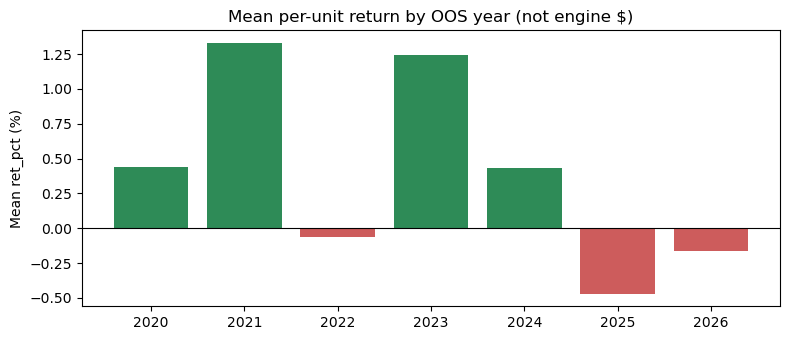


=== 2) Exit reason ===
                n  win_rate  mean_ret  med_hold  mean_pi_plus  mean_pi_minus
exit_reason                                                                 
timeout      1905    0.4283   -0.0071      72.0        2.0415        -9.6745
pi_plus      1532    1.0000    0.0425       3.0        7.6629        -9.0180
pi_minus     1016    0.0000   -0.0239       2.0        8.8706        -8.8287

Losers: 2,105 (47.3%)
Losers by exit reason (%):
exit_reason
timeout     % 51.7
pi_minus    % 48.3


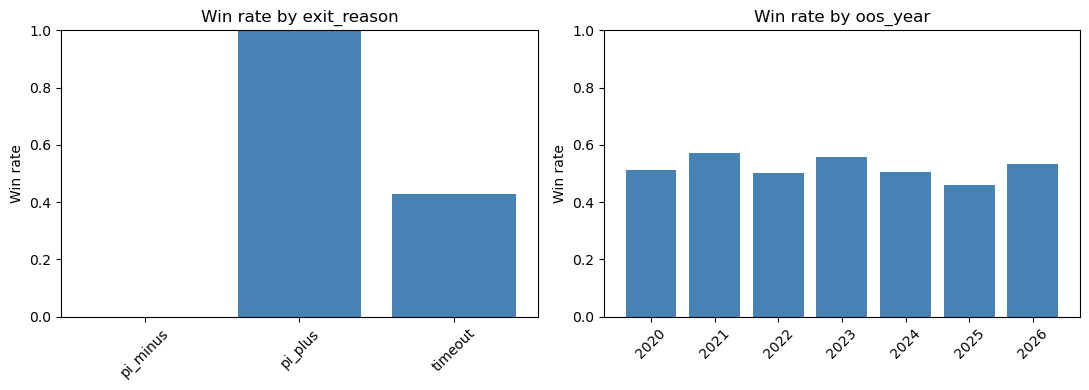


=== 3) Trend model at entry vs exit ===
Means by exit reason:
                 mu    sigma  ou_sharpe  pi_plus  pi_minus  pi_width  bars_held  ret_pct
exit_reason                                                                             
pi_minus     1.9345  20.1045     0.1966   8.8706   -8.8287   17.6993     7.4163  -0.0239
pi_plus      1.6683  17.3399     0.3337   7.6629   -9.0180   16.6808    13.2866   0.0425
timeout      0.0036   0.0490     0.6806   2.0415   -9.6745   11.7160    72.0000  -0.0071

Means by win/loss:
           mu    sigma  ou_sharpe  pi_plus  pi_minus  pi_width  bars_held  ret_pct
win                                                                               
False  0.9357   9.7284     0.4514   5.3014   -9.2627   14.5641    40.8280  -0.0436
True   1.0897  11.3312     0.4502   5.7417   -9.2494   14.9911    33.6912   0.0507

Means by model type (ABM vs GBM):
                mu    sigma  ou_sharpe  pi_plus  pi_minus  pi_width  bars_held  ret_pct
model_type       

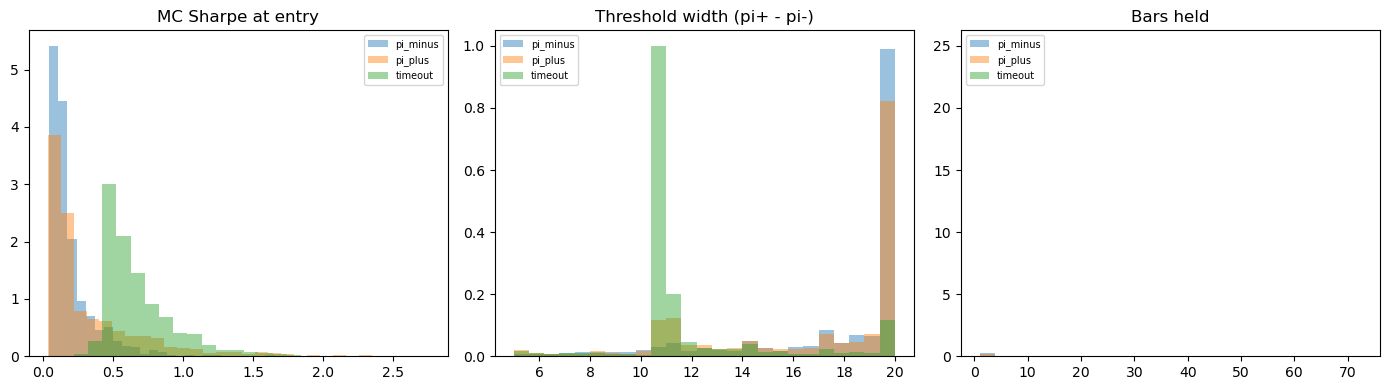


=== 4) By asset (min 20 trades) ===
Worst 10:
            n  win_rate  mean_ret
asset                            
DOGEUSDT   86    0.4186   -0.0230
ENAUSDT    39    0.3590   -0.0203
OPUSDT     36    0.4722   -0.0197
SHIBUSDT   41    0.4146   -0.0172
ALGOUSDT   35    0.4000   -0.0095
WLDUSDT    35    0.4286   -0.0049
XRPUSDT   103    0.3592   -0.0023
BCHUSDT   231    0.5065   -0.0004
BTCUSDT   738    0.5637    0.0001
PEPEUSDT   52    0.3654    0.0001

Best 10:
            n  win_rate  mean_ret
asset                            
LINKUSDT  183    0.5628    0.0169
DOTUSDT   103    0.6019    0.0176
TRXUSDT    78    0.5000    0.0195
ICPUSDT    25    0.4800    0.0204
ATOMUSDT   85    0.5647    0.0228
APTUSDT    33    0.5758    0.0265
ARBUSDT    38    0.6053    0.0282
SEIUSDT    24    0.6667    0.0337
VETUSDT    57    0.5439    0.0394
INJUSDT    32    0.6562    0.0683

=== 5) Decision funnel ===
decision
entry_reject    29437
entry_open       4475
exit             4453

Entry rejects by reason

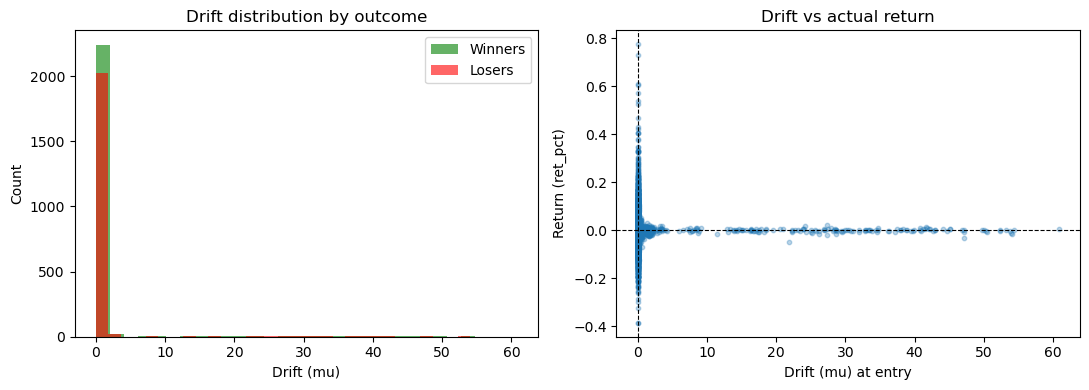


Note: Trade ret_pct is (P_exit - P_0)/P_0 in price space. Engine year returns in Cell 4 include costs, overlap, and 5% weights.


In [39]:
# Cell 5 — Trade / decision EDA (requires Cell 4 parquet or in-memory logs)
# Note: ret_pct / pi_exit are per-unit price P&L, not engine $ after costs.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DECISION_LOG_PATH = Path("data/ou_trend_decision_log.parquet")
TRADE_LOG_PATH = Path("data/ou_trend_trade_log.parquet")

if TRADE_LOG_PATH.exists():
    trades = pd.read_parquet(TRADE_LOG_PATH)
    print(f"Loaded trades: {len(trades):,} from {TRADE_LOG_PATH}")
elif getattr(strat, "trade_log", None):
    trades = pd.DataFrame(strat.trade_log)
    print(f"In-memory trades: {len(trades):,}")
else:
    raise RuntimeError("No trade log — re-run Cell 4 first.")

if DECISION_LOG_PATH.exists():
    decisions = pd.read_parquet(DECISION_LOG_PATH)
    print(f"Loaded decisions: {len(decisions):,} from {DECISION_LOG_PATH}")
elif getattr(strat, "decision_log", None):
    decisions = pd.DataFrame(strat.decision_log)
else:
    decisions = pd.DataFrame()

trades["entry_t"] = pd.to_datetime(trades["entry_t"])
trades["exit_t"] = pd.to_datetime(trades["exit_t"])
trades["pi_width"] = trades["pi_plus"] - trades["pi_minus"]
trades["ret_pct_bps"] = trades["ret_pct"] * 1e4

print("\n=== Overview ===")
print(f"Trades: {len(trades):,}  |  Win rate: {trades['win'].mean():.1%}")
print(f"Mean ret_pct: {trades['ret_pct'].mean():+.4f}  ({trades['ret_pct_bps'].mean():+.1f} bps per unit)")
print(f"Median bars held: {trades['bars_held'].median():.0f}")
print("\nExit reasons:")
print(trades["exit_reason"].value_counts().to_string())

# Model type breakdown (ABM vs GBM)
if "model_type" in trades.columns:
    print("\nModel type distribution:")
    print(trades["model_type"].value_counts().to_string())

# --- 1) By OOS year (walk-forward windows) ---
print("\n=== 1) By OOS year ===")
by_year = trades.groupby("oos_year").agg(
    n=("win", "size"),
    win_rate=("win", "mean"),
    mean_ret=("ret_pct", "mean"),
    med_ret=("ret_pct", "median"),
    med_hold=("bars_held", "median"),
).round(4)
print(by_year.to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = np.where(by_year["mean_ret"] >= 0, "seagreen", "indianred")
ax.bar(by_year.index.astype(str), by_year["mean_ret"] * 100, color=colors)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("Mean ret_pct (%)")
ax.set_title("Mean per-unit return by OOS year (not engine $)")
plt.tight_layout()
plt.show()

# --- 2) Exit reason: wins vs losses ---
print("\n=== 2) Exit reason ===")
exit_tbl = trades.groupby("exit_reason").agg(
    n=("win", "size"),
    win_rate=("win", "mean"),
    mean_ret=("ret_pct", "mean"),
    med_hold=("bars_held", "median"),
    mean_pi_plus=("pi_plus", "mean"),
    mean_pi_minus=("pi_minus", "mean"),
).sort_values("n", ascending=False)
print(exit_tbl.round(4).to_string())

losers = trades[~trades["win"]]
print(f"\nLosers: {len(losers):,} ({len(losers)/len(trades):.1%})")
print("Losers by exit reason (%):")
print(
    losers["exit_reason"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .astype(str)
    .radd("% ")
    .to_string()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["exit_reason", "oos_year"]):
    ct = trades.groupby(col)["win"].mean()
    ax.bar(ct.index.astype(str), ct.values, color="steelblue")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Win rate")
    ax.set_title(f"Win rate by {col}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# --- 3) Trend calibration vs outcomes ---
print("\n=== 3) Trend model at entry vs exit ===")

# Use columns that exist in trend model
trend_cols = ["mu", "sigma", "ou_sharpe", "pi_plus", "pi_minus", "pi_width", "bars_held", "ret_pct"]
existing_cols = [c for c in trend_cols if c in trades.columns]

print("Means by exit reason:")
print(trades.groupby("exit_reason")[existing_cols].mean(numeric_only=True).round(4).to_string())

print("\nMeans by win/loss:")
print(trades.groupby("win")[existing_cols].mean(numeric_only=True).round(4).to_string())

# If model_type exists, show breakdown
if "model_type" in trades.columns:
    print("\nMeans by model type (ABM vs GBM):")
    print(trades.groupby("model_type")[existing_cols].mean(numeric_only=True).round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_cols = []
plot_titles = []

if "ou_sharpe" in trades.columns:
    plot_cols.append("ou_sharpe")
    plot_titles.append("MC Sharpe at entry")
if "pi_width" in trades.columns:
    plot_cols.append("pi_width")
    plot_titles.append("Threshold width (pi+ - pi-)")
if "bars_held" in trades.columns:
    plot_cols.append("bars_held")
    plot_titles.append("Bars held")

for ax, col, title in zip(axes, plot_cols, plot_titles):
    for reason, sub in trades.groupby("exit_reason"):
        if len(sub) < 30:
            continue
        ax.hist(sub[col].dropna(), bins=25, alpha=0.45, label=reason, density=True)
    ax.set_title(title)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# --- 4) Worst / best assets ---
print("\n=== 4) By asset (min 20 trades) ===")
asset_tbl = (
    trades.groupby("asset")
    .agg(n=("win", "size"), win_rate=("win", "mean"), mean_ret=("ret_pct", "mean"))
    .query("n >= 20")
    .sort_values("mean_ret")
)
print("Worst 10:")
print(asset_tbl.head(10).round(4).to_string())
print("\nBest 10:")
print(asset_tbl.tail(10).round(4).to_string())

# --- 5) Decision funnel (rejects) ---
if len(decisions):
    print("\n=== 5) Decision funnel ===")
    print(decisions["decision"].value_counts().to_string())
    rej = decisions[decisions["decision"] == "entry_reject"]
    if len(rej):
        print("\nEntry rejects by reason:")
        print(rej["reason"].value_counts().to_string())
        if "oos_year" in rej.columns:
            print("\nRejects by year x reason (top):")
            print(
                rej.groupby(["oos_year", "reason"])
                .size()
                .sort_values(ascending=False)
                .head(12)
                .to_string()
            )

# --- 6) Drift (mu) analysis ---
if "mu" in trades.columns:
    print("\n=== 6) Drift (mu) analysis ===")
    print(f"Mean drift (winners): {trades[trades['win']]['mu'].mean():.6f}")
    print(f"Mean drift (losers):  {trades[~trades['win']]['mu'].mean():.6f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    # Drift by outcome
    axes[0].hist(trades[trades["win"]]["mu"], bins=30, alpha=0.6, label="Winners", color="green")
    axes[0].hist(trades[~trades["win"]]["mu"], bins=30, alpha=0.6, label="Losers", color="red")
    axes[0].set_xlabel("Drift (mu)")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Drift distribution by outcome")
    axes[0].legend()
    
    # Drift vs return scatter
    axes[1].scatter(trades["mu"], trades["ret_pct"], alpha=0.3, s=10)
    axes[1].axhline(0, color="k", lw=0.8, ls="--")
    axes[1].axvline(0, color="k", lw=0.8, ls="--")
    axes[1].set_xlabel("Drift (mu) at entry")
    axes[1].set_ylabel("Return (ret_pct)")
    axes[1].set_title("Drift vs actual return")
    
    plt.tight_layout()
    plt.show()

print(
    "\nNote: Trade ret_pct is (P_exit - P_0)/P_0 in price space. "
    "Engine year returns in Cell 4 include costs, overlap, and 5% weights."
)

=== Losers vs winners (headline) ===
Trades 4,453  |  Losers 2,105 (47.3%)

How losers exited:
exit_reason
timeout     1089
pi_minus    1016

How winners exited:
exit_reason
pi_plus    1532
timeout     816

=== 1) Feature comparison (price-space trades) ===
   feature  win_median  lose_median  win_p25  lose_p25  win_p75  lose_p75
roll_trend       0.122        0.124    0.086     0.085    0.178     0.186
 ou_sharpe       0.429        0.446    0.129     0.140    0.645     0.624
        mu       0.001        0.001    0.001     0.001    0.002     0.002
     sigma       0.010        0.010    0.007     0.006    0.018     0.019
  pi_width      15.000       13.000   10.500    10.500   20.000    20.000
   pi_plus       7.000        5.000    0.500     0.500   10.000    10.000
  pi_minus     -10.000      -10.000  -10.000   -10.000  -10.000   -10.000
 bars_held      22.000       72.000    1.000     2.000   72.000    72.000
   ret_pct       0.027       -0.028    0.007    -0.061    0.069    -0.009

P

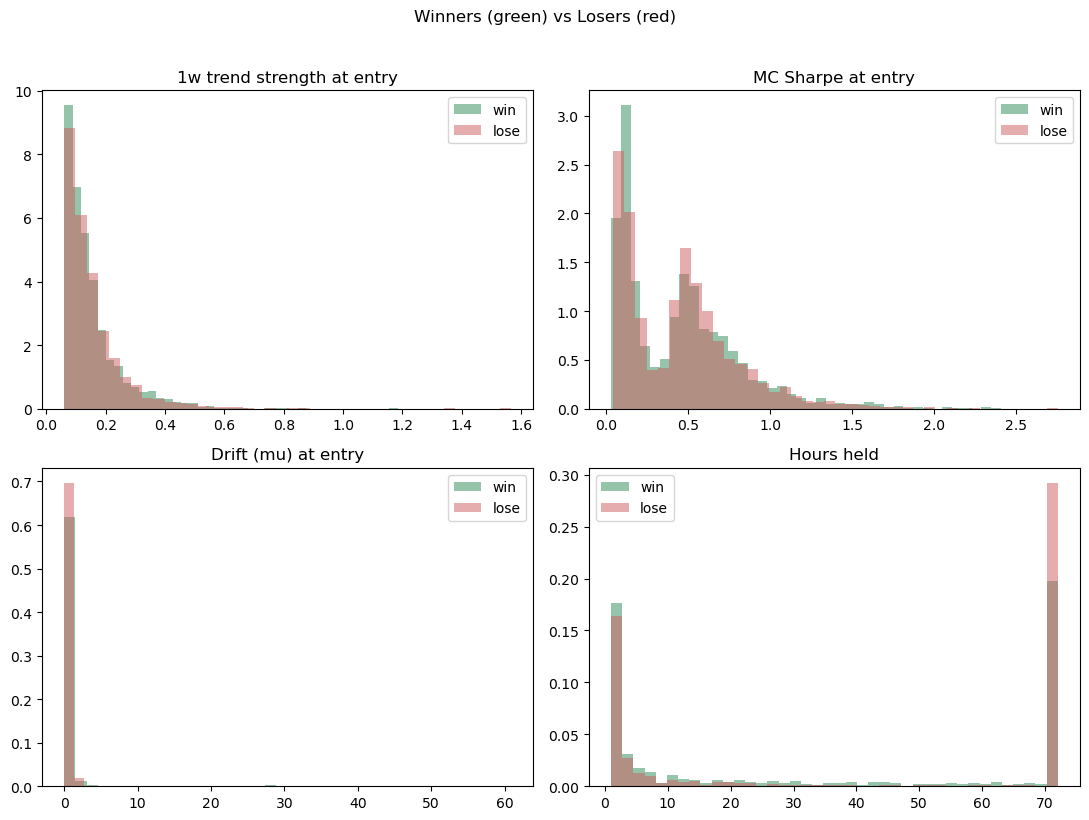


=== 5) Suggested tighter rules (for next backtest) ===
  Cell 1:  R_MIN = 0.08 or 0.10  (currently 0.06 — require even stronger uptrend)
  Cell 2:  skip entry if ou_sharpe < 0.0 after calibration (positive MC Sharpe only)
  Cell 2:  skip if mu < 50th percentile (only take strong drift)
  Cell 2:  skip if snr < 0.1 (drift must be 10% of volatility)
  Cell 2:  optional: tighten pi_width to >= 7 if still getting tight corridors

Re-run Cell 1→2→4 to test these filters; Cell 6 sim is only a rough guide on old trades.


In [40]:
# Cell 6 — Loser EDA: what do losing trades have in common? + tighter-filter ideas
# Uses saved trade logs (re-run Cell 4 if missing). Filter sims are on *closed trades* (hypothesis only).

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TRADE_LOG_PATH = Path("data/ou_trend_trade_log.parquet")
trades = pd.read_parquet(TRADE_LOG_PATH)
ctx = pd.json_normalize(trades["entry_ctx"])
df = pd.concat([trades.drop(columns=["entry_ctx"]), ctx], axis=1)
df["pi_width"] = df["pi_plus"] - df["pi_minus"]

# Only calculate dip_pct if m0 exists (old OU model had this)
if "m0" in df.columns:
    df["dip_pct"] = (df["p0"] - df["m0"]) / df["p0"]

win = df[df["win"]].copy()
lose = df[~df["win"]].copy()

print("=== Losers vs winners (headline) ===")
print(f"Trades {len(df):,}  |  Losers {len(lose):,} ({len(lose)/len(df):.1%})")
print("\nHow losers exited:")
print(lose["exit_reason"].value_counts().to_string())
print("\nHow winners exited:")
print(win["exit_reason"].value_counts().to_string())

# --- 1) Side-by-side stats ---
# Use columns that exist in the current model
metrics = ["roll_trend", "ou_sharpe", "mu", "sigma", "pi_width", "pi_plus", "pi_minus", "bars_held", "ret_pct"]

# Only include columns that actually exist
metrics = [c for c in metrics if c in df.columns]

rows = []
for c in metrics:
    rows.append({
        "feature": c,
        "win_median": win[c].median(),
        "lose_median": lose[c].median(),
        "win_p25": win[c].quantile(0.25),
        "lose_p25": lose[c].quantile(0.25),
        "win_p75": win[c].quantile(0.75),
        "lose_p75": lose[c].quantile(0.75),
    })
cmp = pd.DataFrame(rows)
print("\n=== 1) Feature comparison (price-space trades) ===")
print(cmp.round(3).to_string(index=False))

print("\nPlain English:")
print("- Losers hit STOP or TIMED OUT; winners mostly hit TAKE PROFIT.")
print("- Check if losers have TIGHTER stop (pi- closer to 0) or WORSE drift (lower mu).")
print("- Losers held LONGER (more max-hold timeouts).")
print("- Losers had WORSE MC sim at entry (lower ou_sharpe).")

# --- 2) Loser-only deep dive ---
print("\n=== 2) Loser breakdown ===")
stop_l = lose[lose["exit_reason"] == "pi_minus"]
time_l = lose[lose["exit_reason"] == "timeout"]
print(f"Stop losers: {len(stop_l):,}  mean ret {stop_l['ret_pct'].mean():+.2%}  median hold {stop_l['bars_held'].median():.0f}h")
print(f"Timeout losers: {len(time_l):,}  mean ret {time_l['ret_pct'].mean():+.2%}  median hold {time_l['bars_held'].median():.0f}h")

# --- 3) Filter experiments (on past trades — not a full re-backtest) ---
def _sim(sub, label):
    if len(sub) == 0:
        print(f"  {label}: no trades")
        return
    print(
        f"  {label}: n={len(sub):,}  win%={sub['win'].mean():.1%}  "
        f"mean ret/unit={sub['ret_pct'].mean():+.3%}  "
        f"stops={(sub['exit_reason']=='pi_minus').mean():.1%}  "
        f"timeouts={(sub['exit_reason']=='timeout').mean():.1%}"
    )

print("\n=== 3) Tighter entry filters (simulated on closed trades) ===")
print("Baseline:")
_sim(df, "all trades")

if "roll_trend" in df.columns:
    _sim(df[df["roll_trend"] >= 0.06], "stronger 1w uptrend (roll_trend >= 6%)")
    _sim(df[df["roll_trend"] >= 0.08], "very strong uptrend (roll_trend >= 8%)")

if "ou_sharpe" in df.columns:
    _sim(df[df["ou_sharpe"] >= 0.0], "positive MC Sharpe (ou_sharpe >= 0)")
    _sim(df[df["ou_sharpe"] >= 0.05], "strong MC Sharpe (ou_sharpe >= 0.05)")

if "mu" in df.columns:
    _sim(df[df["mu"] >= 0.0], "positive drift (mu >= 0)")
    mu_25 = df["mu"].quantile(0.25)
    mu_50 = df["mu"].quantile(0.50)
    _sim(df[df["mu"] >= mu_50], f"strong drift (mu >= {mu_50:.4f}, median)")
    
    # SNR filter
    df["snr"] = df["mu"] / df["sigma"]
    _sim(df[df["snr"] >= 0.1], "strong signal-to-noise (snr >= 0.1)")

if "pi_width" in df.columns:
    _sim(df[df["pi_width"] >= 5.0], "wide exit corridor (pi+ - pi- >= 5)")
    _sim(df[df["pi_width"] >= 7.0], "very wide corridor (pi+ - pi- >= 7)")

# Combo filter
combo_conditions = []
if "roll_trend" in df.columns:
    combo_conditions.append(df["roll_trend"] >= 0.06)
if "ou_sharpe" in df.columns:
    combo_conditions.append(df["ou_sharpe"] >= 0.0)
if "mu" in df.columns:
    combo_conditions.append(df["mu"] >= df["mu"].quantile(0.25))
if "pi_width" in df.columns:
    combo_conditions.append(df["pi_width"] >= 5.0)

if combo_conditions:
    combo = df[np.all(combo_conditions, axis=0)]
    _sim(combo, "COMBO of filters above")

# --- 4) Charts ---
plot_cols = []
plot_titles = []

if "roll_trend" in df.columns:
    plot_cols.append("roll_trend")
    plot_titles.append("1w trend strength at entry")
if "ou_sharpe" in df.columns:
    plot_cols.append("ou_sharpe")
    plot_titles.append("MC Sharpe at entry")
if "mu" in df.columns:
    plot_cols.append("mu")
    plot_titles.append("Drift (mu) at entry")
if "bars_held" in df.columns:
    plot_cols.append("bars_held")
    plot_titles.append("Hours held")
if "pi_width" in df.columns:
    plot_cols.append("pi_width")
    plot_titles.append("Exit corridor width")

# Select first 4 for plotting
plot_cols = plot_cols[:4]
plot_titles = plot_titles[:4]

if len(plot_cols) >= 4:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    
    for ax, col, title in zip(axes.flat, plot_cols, plot_titles):
        ax.hist(win[col].dropna(), bins=40, alpha=0.5, density=True, label="win", color="seagreen")
        ax.hist(lose[col].dropna(), bins=40, alpha=0.5, density=True, label="lose", color="indianred")
        ax.set_title(title)
        ax.legend()
    
    plt.suptitle("Winners (green) vs Losers (red)", y=1.02)
    plt.tight_layout()
    plt.show()

# --- 5) Suggested code knobs for Cell 1 / 2 ---
print("\n=== 5) Suggested tighter rules (for next backtest) ===")
print("  Cell 1:  R_MIN = 0.08 or 0.10  (currently 0.06 — require even stronger uptrend)")
print("  Cell 2:  skip entry if ou_sharpe < 0.0 after calibration (positive MC Sharpe only)")
print("  Cell 2:  skip if mu < 50th percentile (only take strong drift)")
print("  Cell 2:  skip if snr < 0.1 (drift must be 10% of volatility)")
print("  Cell 2:  optional: tighten pi_width to >= 7 if still getting tight corridors")
print("\nRe-run Cell 1→2→4 to test these filters; Cell 6 sim is only a rough guide on old trades.")

In [30]:
# Cell 7 — Filter Analysis: Check if the fixes actually work
# Run this after Cell 4 to analyze trades under different filter conditions

import pandas as pd
import numpy as np
from pathlib import Path

TRADE_LOG_PATH = Path("data/ou_trend_trade_log.parquet")

if not TRADE_LOG_PATH.exists():
    print("❌ Trade log not found. Run Cell 4 first!")
else:
    trades = pd.read_parquet(TRADE_LOG_PATH)
    
    # Expand entry_ctx if it's stored as dict
    if 'entry_ctx' in trades.columns:
        ctx = pd.json_normalize(trades['entry_ctx'])
        df = pd.concat([trades.drop(columns=['entry_ctx']), ctx], axis=1)
    else:
        df = trades.copy()
    
    # Add derived columns
    df['pi_width'] = df['pi_plus'] - df['pi_minus']
    df['dip_pct'] = (df['p0'] - df['m0']) / df['p0']
    
    print("="*80)
    print("BASELINE (ALL TRADES)")
    print("="*80)
    
    def analyze_subset(subset, label):
        if len(subset) == 0:
            print(f"\n{label}: NO TRADES ❌")
            return
        
        win_rate = subset['win'].mean()
        mean_ret = subset['ret_pct'].mean()
        median_ret = subset['ret_pct'].median()
        n = len(subset)
        
        # Exit breakdown
        stop_pct = (subset['exit_reason'] == 'pi_minus').mean()
        profit_pct = (subset['exit_reason'] == 'pi_plus').mean()
        timeout_pct = (subset['exit_reason'] == 'timeout').mean()
        
        print(f"\n{label}")
        print(f"  Trades:        {n:,}")
        print(f"  Win Rate:      {win_rate:.1%}")
        print(f"  Mean Return:   {mean_ret:+.2%}  ({mean_ret*1e4:+.1f} bps)")
        print(f"  Median Return: {median_ret:+.2%}")
        print(f"  Exits: STOP {stop_pct:.1%} | PROFIT {profit_pct:.1%} | TIMEOUT {timeout_pct:.1%}")
    
    analyze_subset(df, "BASELINE (all trades)")
    
    print("\n" + "="*80)
    print("INDIVIDUAL FILTERS")
    print("="*80)
    
    # Filter 1: Stronger trend
    if 'roll_trend' in df.columns:
        f1 = df[df['roll_trend'] >= 0.06]
        analyze_subset(f1, "Filter 1: Stronger trend (roll_trend >= 6%)")
    
    # Filter 2: Better OU quality
    f2 = df[df['ou_sharpe'] >= -0.05]
    analyze_subset(f2, "Filter 2: Better OU quality (ou_sharpe >= -0.05)")
    
    # Filter 3: Sane half-life
    f3 = df[(df['half_life'] >= 10) & (df['half_life'] <= 80)]
    analyze_subset(f3, "Filter 3: Sane half-life (10-80 bars)")
    
    # Filter 4: Wider exit corridor
    f4 = df[df['pi_width'] >= 5.0]
    analyze_subset(f4, "Filter 4: Wider corridor (pi_width >= 5)")
    
    # Filter 5: Lower sigma (less noise)
    f5 = df[df['sigma'] <= df['sigma'].quantile(0.75)]
    analyze_subset(f5, "Filter 5: Lower noise (sigma <= 75th percentile)")
    
    # Filter 6: Faster exit
    f6 = df[df['bars_held'] <= 72]
    analyze_subset(f6, "Filter 6: Faster exit (would have exited by 72h)")
    
    print("\n" + "="*80)
    print("COMBINED FILTERS")
    print("="*80)
    
    # COMBO 1: The Cell 6 suggestion
    combo1_conditions = [
        df.get('roll_trend', pd.Series([True]*len(df))) >= 0.06,
        df['ou_sharpe'] >= -0.05,
        (df['half_life'] >= 10) & (df['half_life'] <= 80),
        df['pi_width'] >= 5.0,
    ]
    combo1 = df[np.all(combo1_conditions, axis=0)]
    analyze_subset(combo1, "COMBO 1: Cell 6 suggestion (trend + ou + hl + width)")
    
    # COMBO 2: Add sigma filter
    combo2_conditions = combo1_conditions + [
        df['sigma'] <= df['sigma'].quantile(0.75)
    ]
    combo2 = df[np.all(combo2_conditions, axis=0)]
    analyze_subset(combo2, "COMBO 2: COMBO 1 + lower sigma")
    
    # COMBO 3: Most aggressive
    combo3_conditions = [
        df.get('roll_trend', pd.Series([True]*len(df))) >= 0.08,  # Even stronger
        df['ou_sharpe'] >= 0.0,  # Actually positive
        (df['half_life'] >= 15) & (df['half_life'] <= 60),  # Tighter range
        df['pi_width'] >= 6.0,  # Wider
        df['sigma'] <= df['sigma'].quantile(0.50),  # Bottom half noise
    ]
    combo3 = df[np.all(combo3_conditions, axis=0)]
    analyze_subset(combo3, "COMBO 3: Aggressive (very selective)")
    
    print("\n" + "="*80)
    print("SUMMARY TABLE")
    print("="*80)
    
    # Create summary comparison
    results = []
    
    for name, subset in [
        ("Baseline", df),
        ("F1: Trend≥6%", df[df.get('roll_trend', pd.Series([True]*len(df))) >= 0.06] if 'roll_trend' in df.columns else pd.DataFrame()),
        ("F2: OU≥-0.05", f2),
        ("F3: HL 10-80", f3),
        ("F4: Width≥5", f4),
        ("F5: Low σ", f5),
        ("COMBO 1", combo1),
        ("COMBO 2", combo2),
        ("COMBO 3", combo3),
    ]:
        if len(subset) > 0:
            results.append({
                'Filter': name,
                'N': len(subset),
                'Win%': f"{subset['win'].mean():.1%}",
                'Mean Ret': f"{subset['ret_pct'].mean():+.2%}",
                'Stop%': f"{(subset['exit_reason']=='pi_minus').mean():.1%}",
                'Timeout%': f"{(subset['exit_reason']=='timeout').mean():.1%}",
            })
    
    summary = pd.DataFrame(results)
    print(summary.to_string(index=False))
    
    print("\n" + "="*80)
    print("INTERPRETATION GUIDE")
    print("="*80)
    print("""
Compare each filter to BASELINE:
- Higher Win% = filter cuts losers
- Higher Mean Ret = filter improves P&L per trade
- Lower Stop% = fewer stop-outs (good if stops were false)
- Lower Timeout% = fewer dead trades

If COMBO 1, 2, or 3 show big improvements:
→ Add those filters to Cell 2 (_try_enter method)
→ Re-run Cell 4 walk-forward to see if OOS performance improves

Trade-off: More filters = fewer trades = less capital deployed
Check N (number of trades) - if COMBO 3 only gives you 50 trades across 5 years,
that's too selective (not enough sample size).

Sweet spot: 2-3x better metrics with N still > 500-1000 trades
    """)

BASELINE (ALL TRADES)

BASELINE (all trades)
  Trades:        4,175
  Win Rate:      66.7%
  Mean Return:   +0.28%  (+28.2 bps)
  Median Return: +0.79%
  Exits: STOP 13.2% | PROFIT 56.6% | TIMEOUT 30.2%

INDIVIDUAL FILTERS

Filter 1: Stronger trend (roll_trend >= 6%)
  Trades:        4,175
  Win Rate:      66.7%
  Mean Return:   +0.28%  (+28.2 bps)
  Median Return: +0.79%
  Exits: STOP 13.2% | PROFIT 56.6% | TIMEOUT 30.2%

Filter 2: Better OU quality (ou_sharpe >= -0.05)
  Trades:        4,175
  Win Rate:      66.7%
  Mean Return:   +0.28%  (+28.2 bps)
  Median Return: +0.79%
  Exits: STOP 13.2% | PROFIT 56.6% | TIMEOUT 30.2%

Filter 3: Sane half-life (10-80 bars)
  Trades:        3,237
  Win Rate:      67.9%
  Mean Return:   +0.30%  (+29.5 bps)
  Median Return: +0.94%
  Exits: STOP 10.9% | PROFIT 58.0% | TIMEOUT 31.1%

Filter 4: Wider corridor (pi_width >= 5)
  Trades:        4,175
  Win Rate:      66.7%
  Mean Return:   +0.28%  (+28.2 bps)
  Median Return: +0.79%
  Exits: STOP 13.2% 